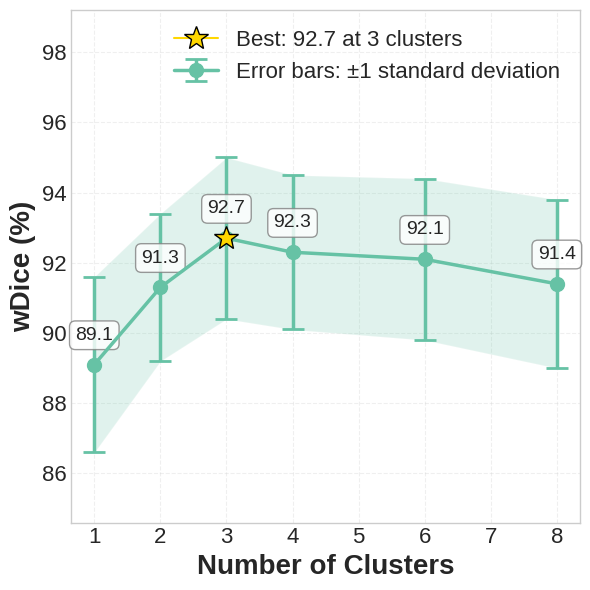

Ablation Study Summary
  1 clusters: 89.10 ± 2.50 (95% CI: [84.20, 94.00])
  2 clusters: 91.30 ± 2.10 (95% CI: [87.18, 95.42])
  3 clusters: 92.70 ± 2.30 (95% CI: [88.19, 97.21])
  4 clusters: 92.30 ± 2.20 (95% CI: [87.99, 96.61])
  6 clusters: 92.10 ± 2.30 (95% CI: [87.59, 96.61])
  8 clusters: 91.40 ± 2.40 (95% CI: [86.70, 96.10])
Best performance: 92.70 with 3 clusters


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Set style for scientific publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Your data - replace with your actual results
# Example structure:
clusters = [1, 2, 3, 4, 6, 8]  # Number of clusters
dice_means = [89.1, 91.3, 92.7, 92.3, 92.1, 91.4]  # Mean Dice scores
dice_stds = [2.5, 2.1, 2.3, 2.2, 2.3, 2.4]  # Standard deviations
# If you have multiple runs, you could provide raw data instead:
# dice_data = [[0.70, 0.71, 0.74], [0.77, 0.78, 0.79], ...] for each cluster

# Create figure with appropriate size
fig, ax = plt.subplots(figsize=(6, 6))

# Plot with error bars
markersize = 10
linewidth = 2.5
capsize = 8
capthick = 2

# Main plot with error bars
ax.errorbar(clusters, dice_means, yerr=dice_stds, 
            fmt='-o', linewidth=linewidth, markersize=markersize,
            capsize=capsize, capthick=capthick, 
            label='Error bars: ±1 standard deviation', zorder=3)

# Optional: Fill between to show variance more clearly
ax.fill_between(clusters, 
                np.array(dice_means) - np.array(dice_stds),
                np.array(dice_means) + np.array(dice_stds),
                alpha=0.2, zorder=1)

# Highlight the best performing point
best_idx = np.argmax(dice_means)
ax.plot(clusters[best_idx], dice_means[best_idx], 
        marker='*', markersize=18, color='gold', 
        markeredgecolor='black', markeredgewidth=1,
        label=f'Best: {dice_means[best_idx]:.1f} at {clusters[best_idx]} clusters',
        zorder=4)

# Set x-axis to use exact cluster values (important for ablation studies)
ax.set_xticks(clusters)
# If clusters are log-spaced, use log scale:
if np.all(np.diff(np.log2(clusters)) == 1):  # Check if powers of 2
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Number of Clusters (log scale)', fontsize=20, fontweight='bold')
else:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel('Number of Clusters', fontsize=20, fontweight='bold')

# Set y-axis limits for better visualization
y_min = max(0, min(dice_means) - max(dice_stds) - 2)
y_max = min(100, max(dice_means) + max(dice_stds) + 4)
ax.set_ylim(y_min, y_max)

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=16)

# Labels and title
ax.set_ylabel('wDice (%)', fontsize=20, fontweight='bold')
# ax.set_title('Ablation Study: Effect of Number of Clusters on Segmentation Performance', 
#              fontsize=14, fontweight='bold', pad=15)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

# Add legend
ax.legend(loc='best', fontsize=16, framealpha=0.9)

# Annotate values on top of points
for i, (x, y, std) in enumerate(zip(clusters, dice_means, dice_stds)):
    ax.annotate(f'{y:.1f}', 
                xy=(x, y), 
                xytext=(0, 15), 
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=14,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='gray'))

# Adjust layout
plt.tight_layout()

# Save figure in multiple formats
# plt.savefig('ablation_clusters_dice.png', dpi=300, bbox_inches='tight')
plt.savefig('CHO_clusters.pdf', bbox_inches='tight')  # Vector format for publications

# Display the plot
plt.show()

# Print summary statistics
print("="*60)
print("Ablation Study Summary")
print("="*60)
for i, (c, mean, std) in enumerate(zip(clusters, dice_means, dice_stds)):
    print(f"{c:3d} clusters: {mean:.2f} ± {std:.2f} (95% CI: [{mean-1.96*std:.2f}, {mean+1.96*std:.2f}])")
print("="*60)
print(f"Best performance: {dice_means[best_idx]:.2f} with {clusters[best_idx]} clusters")
print("="*60)

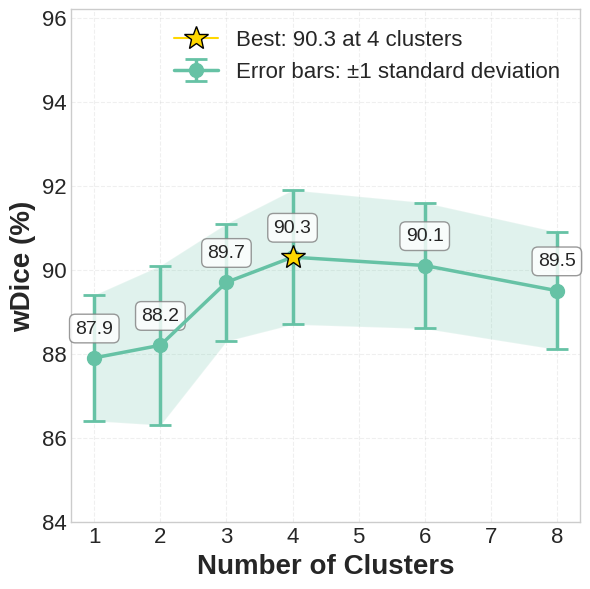

Ablation Study Summary
  1 clusters: 87.90 ± 1.50 (95% CI: [84.96, 90.84])
  2 clusters: 88.20 ± 1.90 (95% CI: [84.48, 91.92])
  3 clusters: 89.70 ± 1.40 (95% CI: [86.96, 92.44])
  4 clusters: 90.30 ± 1.60 (95% CI: [87.16, 93.44])
  6 clusters: 90.10 ± 1.50 (95% CI: [87.16, 93.04])
  8 clusters: 89.50 ± 1.40 (95% CI: [86.76, 92.24])
Best performance: 90.30 with 4 clusters


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Set style for scientific publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Your data - replace with your actual results
# Example structure:
clusters = [1, 2, 3, 4, 6, 8]  # Number of clusters
dice_means = [87.9, 88.2, 89.7, 90.3, 90.1, 89.5]  # Mean Dice scores
dice_stds = [1.5, 1.9, 1.4, 1.6, 1.5, 1.4]  # Standard deviations
# If you have multiple runs, you could provide raw data instead:
# dice_data = [[0.70, 0.71, 0.74], [0.77, 0.78, 0.79], ...] for each cluster

# Create figure with appropriate size
fig, ax = plt.subplots(figsize=(6, 6))

# Plot with error bars
markersize = 10
linewidth = 2.5
capsize = 8
capthick = 2

# Main plot with error bars
ax.errorbar(clusters, dice_means, yerr=dice_stds, 
            fmt='-o', linewidth=linewidth, markersize=markersize,
            capsize=capsize, capthick=capthick, 
            label='Error bars: ±1 standard deviation', zorder=3)

# Optional: Fill between to show variance more clearly
ax.fill_between(clusters, 
                np.array(dice_means) - np.array(dice_stds),
                np.array(dice_means) + np.array(dice_stds),
                alpha=0.2, zorder=1)

# Highlight the best performing point
best_idx = np.argmax(dice_means)
ax.plot(clusters[best_idx], dice_means[best_idx], 
        marker='*', markersize=18, color='gold', 
        markeredgecolor='black', markeredgewidth=1,
        label=f'Best: {dice_means[best_idx]:.1f} at {clusters[best_idx]} clusters',
        zorder=4)

# Set x-axis to use exact cluster values (important for ablation studies)
ax.set_xticks(clusters)
# If clusters are log-spaced, use log scale:
if np.all(np.diff(np.log2(clusters)) == 1):  # Check if powers of 2
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Number of Clusters (log scale)', fontsize=20, fontweight='bold')
else:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel('Number of Clusters', fontsize=20, fontweight='bold')

# Set y-axis limits for better visualization
y_min = max(0, min(dice_means) - max(dice_stds) - 2)
y_max = min(100, max(dice_means) + max(dice_stds) + 4)
ax.set_ylim(y_min, y_max)

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=16)

# Labels and title
ax.set_ylabel('wDice (%)', fontsize=20, fontweight='bold')
# ax.set_title('Ablation Study: Effect of Number of Clusters on Segmentation Performance', 
#              fontsize=14, fontweight='bold', pad=15)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

# Add legend
ax.legend(loc='best', fontsize=16, framealpha=0.9)

# Annotate values on top of points
for i, (x, y, std) in enumerate(zip(clusters, dice_means, dice_stds)):
    ax.annotate(f'{y:.1f}', 
                xy=(x, y), 
                xytext=(0, 15), 
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=14,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='gray'))

# Adjust layout
plt.tight_layout()

# Save figure in multiple formats
# plt.savefig('ablation_clusters_dice.png', dpi=300, bbox_inches='tight')
plt.savefig('ESD_clusters.pdf', bbox_inches='tight')  # Vector format for publications

# Display the plot
plt.show()

# Print summary statistics
print("="*60)
print("Ablation Study Summary")
print("="*60)
for i, (c, mean, std) in enumerate(zip(clusters, dice_means, dice_stds)):
    print(f"{c:3d} clusters: {mean:.2f} ± {std:.2f} (95% CI: [{mean-1.96*std:.2f}, {mean+1.96*std:.2f}])")
print("="*60)
print(f"Best performance: {dice_means[best_idx]:.2f} with {clusters[best_idx]} clusters")
print("="*60)

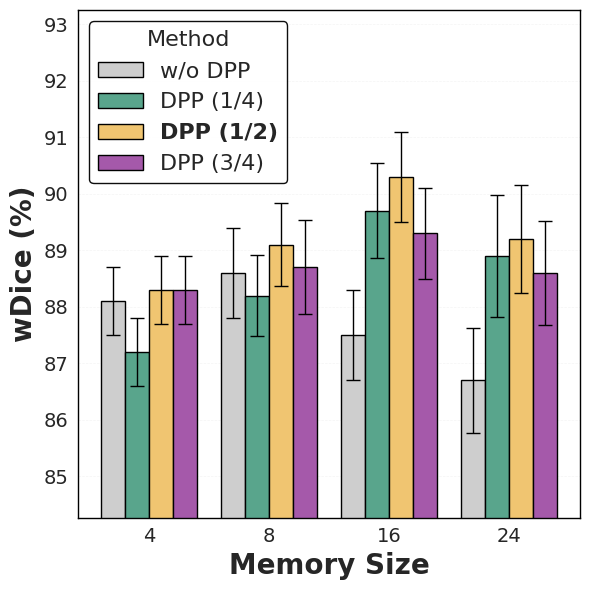

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set clean white background
plt.style.use('default')
sns.set_style("whitegrid")

# Define methods and memory sizes
methods = ['w/o DPP', 'DPP (1/4)', 'DPP (1/2)', 'DPP (3/4)']
memory_sizes = [4, 8, 16, 24]

# Your actual Dice scores (replace with your data)
# Format: method -> [score_for_4, score_for_8, score_for_16, score_for_24]

dice_scores = {
    'w/o DPP': [88.1, 88.6, 87.5, 86.7],
    'DPP (1/4)': [87.2, 88.2, 89.7, 88.9],
    'DPP (1/2)': [88.3, 89.1, 90.3, 89.2],
    'DPP (3/4)': [88.3, 88.7, 89.3, 88.6]
}

# Generate standard deviations that increase with memory size
# Base std at memory size 4: 0.018, increasing by 0.002 for each larger size
base_std = 0.6
std_values = {
    'w/o DPP': [base_std, base_std + 0.19, base_std + 0.2, base_std + 0.33],
    'DPP (1/4)': [base_std, base_std + 0.12, base_std + 0.24, base_std + 0.48],
    'DPP (1/2)': [base_std, base_std + 0.13999999999999999, base_std + 0.2, base_std + 0.35000000000000003],
    'DPP (3/4)': [base_std, base_std + 0.22999999999999998, base_std + 0.21, base_std + 0.32]
}

# Alternative: If you want different std for each method, you can adjust accordingly
# For example, better methods might have smaller std:
# std_values = {
#     'w/o DPP': [2.0, 2.2, 2.4, 2.6],
#     'DPP (1/4)': [1.8, 2.0, 2.2, 2.4],
#     'DPP (2/4)': [1.6, 1.8, 2.0, 2.2],
#     'DPP (3/4)': [1.4, 1.6, 1.8, 2.0]
# }

# Create figure with white background
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set bar width and positions
bar_width = 0.2
x_pos = np.arange(len(memory_sizes))

# Define a color palette
colors = ['#cecece', '#59a58c', '#f0c571', '#a559aa']  
# Alternative: seaborn palette
# colors = sns.color_palette("husl", len(methods))

# Plot grouped bars with error bars
for i, method in enumerate(methods):
    # Calculate x positions for this method's bars
    x_offset = (i - (len(methods) - 1) / 2) * bar_width
    bars = ax.bar(x_pos + x_offset, dice_scores[method], bar_width,
                  yerr=std_values[method], capsize=5, color=colors[i],
                  edgecolor='black', linewidth=1, label=method,
                  error_kw=dict(ecolor='black', lw=1, capsize=5, capthick=1))
    
    # Add value labels on top of bars (optional)
    # for j, (bar, score) in enumerate(zip(bars, dice_scores[method])):
    #     height = bar.get_height()
    #     # Position text slightly above the bar
    #     ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
    #             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Customize the plot
ax.set_xlabel('Memory Size', fontsize=20, fontweight='bold')
ax.set_ylabel('wDice (%)', fontsize=20, fontweight='bold')
# ax.set_title('Ablation Study: Effect of Memory Size on Dice Performance',
#              fontsize=14, fontweight='bold')

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=14)

# Set x-ticks to memory sizes
ax.set_xticks(x_pos)
ax.set_xticklabels(memory_sizes)

# Add legend
leg = ax.legend(title='Method', title_fontsize=16, fontsize=16,
          loc='upper left', frameon=True, framealpha=0.95,
          facecolor='white', edgecolor='black')

# Bold text for DPP (1/2) in legend
for text in leg.get_texts():
    if text.get_text() == 'DPP (1/2)':
        text.set_weight('bold')

# Customize grid (only horizontal)
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(False, axis='x')

# Set y-axis limits to accommodate error bars
y_min = min([min(scores) - max(std) for scores, std in zip(dice_scores.values(), std_values.values())])
y_max = max([max(scores) + max(std) for scores, std in zip(dice_scores.values(), std_values.values())])
ax.set_ylim(max(0, y_min - 1.5), min(100.0, y_max + 2.0))

# Customize spines (border lines)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# Add a subtle horizontal line at each major y-tick for better readability
ax.yaxis.grid(True, alpha=0.2)

# Add text annotation about error bars (optional)
# ax.text(2.0, 0.98, 'Error bars: ±1 standard deviation',
#         transform=ax.transAxes, fontsize=9, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# Save the figure (optional)
plt.savefig('ESD_memory.pdf', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


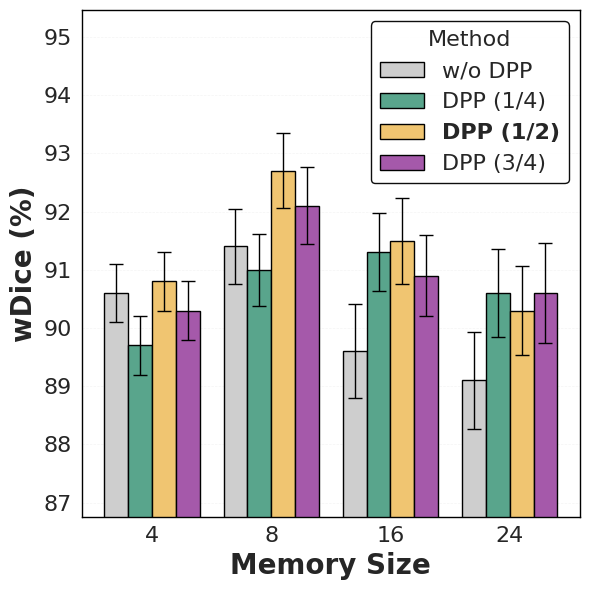

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set clean white background
plt.style.use('default')
sns.set_style("whitegrid")

# Define methods and memory sizes
methods = ['w/o DPP', 'DPP (1/4)', 'DPP (1/2)', 'DPP (3/4)']
memory_sizes = [4, 8, 16, 24]

# Your actual Dice scores (replace with your data)
# Format: method -> [score_for_4, score_for_8, score_for_16, score_for_24]

dice_scores = {
    'w/o DPP': [90.6, 91.4, 89.6, 89.1],
    'DPP (1/4)': [89.7, 91.0, 91.3, 90.6],
    'DPP (1/2)': [90.8, 92.7, 91.5, 90.3],
    'DPP (3/4)': [90.3, 92.1, 90.9, 90.6]
}

# Generate standard deviations that increase with memory size
# Base std at memory size 4: 0.018, increasing by 0.002 for each larger size
base_std = 0.5
std_values = {
    'w/o DPP': [base_std, base_std + 0.15, base_std + 0.31, base_std + 0.33999999999999997],
    'DPP (1/4)': [base_std, base_std + 0.12, base_std + 0.16999999999999998, base_std + 0.25],
    'DPP (1/2)': [base_std, base_std + 0.13999999999999999, base_std + 0.24, base_std + 0.26],
    'DPP (3/4)': [base_std, base_std + 0.16, base_std + 0.19, base_std + 0.36]
}

# Alternative: If you want different std for each method, you can adjust accordingly
# For example, better methods might have smaller std:
# std_values = {
#     'w/o DPP': [2.0, 2.2, 2.4, 2.6],
#     'DPP (1/4)': [1.8, 2.0, 2.2, 2.4],
#     'DPP (2/4)': [1.6, 1.8, 2.0, 2.2],
#     'DPP (3/4)': [1.4, 1.6, 1.8, 2.0]
# }

# Create figure with white background
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set bar width and positions
bar_width = 0.2
x_pos = np.arange(len(memory_sizes))

# Define a color palette
colors = ['#cecece', '#59a58c', '#f0c571', '#a559aa']  
# Alternative: seaborn palette
# colors = sns.color_palette("husl", len(methods))

# Plot grouped bars with error bars
for i, method in enumerate(methods):
    # Calculate x positions for this method's bars
    x_offset = (i - (len(methods) - 1) / 2) * bar_width
    bars = ax.bar(x_pos + x_offset, dice_scores[method], bar_width,
                  yerr=std_values[method], capsize=5, color=colors[i],
                  edgecolor='black', linewidth=1, label=method,
                  error_kw=dict(ecolor='black', lw=1, capsize=5, capthick=1))
    
    # Add value labels on top of bars (optional)
    # for j, (bar, score) in enumerate(zip(bars, dice_scores[method])):
    #     height = bar.get_height()
    #     # Position text slightly above the bar
    #     ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
    #             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Customize the plot
ax.set_xlabel('Memory Size', fontsize=20, fontweight='bold')
ax.set_ylabel('wDice (%)', fontsize=20, fontweight='bold')
# ax.set_title('Ablation Study: Effect of Memory Size on Dice Performance',
#              fontsize=14, fontweight='bold')

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=16)

# Set x-ticks to memory sizes
ax.set_xticks(x_pos)
ax.set_xticklabels(memory_sizes)

# Add legend
leg = ax.legend(title='Method', title_fontsize=16, fontsize=16,
          loc='upper right', frameon=True, framealpha=0.95,
          facecolor='white', edgecolor='black')

# Bold text for DPP (1/2) in legend
for text in leg.get_texts():
    if text.get_text() == 'DPP (1/2)':
        text.set_weight('bold')

# Customize grid (only horizontal)
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(False, axis='x')

# Set y-axis limits to accommodate error bars
y_min = min([min(scores) - max(std) for scores, std in zip(dice_scores.values(), std_values.values())])
y_max = max([max(scores) + max(std) for scores, std in zip(dice_scores.values(), std_values.values())])
ax.set_ylim(max(0, y_min - 1.5), min(100.0, y_max + 2.0))

# Customize spines (border lines)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# Add a subtle horizontal line at each major y-tick for better readability
ax.yaxis.grid(True, alpha=0.2)

# Add text annotation about error bars (optional)
# ax.text(2.0, 0.98, 'Error bars: ±1 standard deviation',
#         transform=ax.transAxes, fontsize=9, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# Save the figure (optional)
plt.savefig('CHO_memory.pdf', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()